In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("arjunbasandrai/25-indian-bird-species-with-226k-images")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 9.33G/9.33G [01:45<00:00, 95.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4):
['training_set', 'training_data']


In [ ]:
print(f"Contents of the 'training_set' directory: {os.listdir(os.path.join(path, 'training_set'))}")
print(f"Contents of the 'training_data' directory: {os.listdir(os.path.join(path, 'training_data'))}")

Contents of the 'training_set' directory: ['training_set']
Contents of the 'training_data' directory: ['train', 'test', 'val']



--- Sample Images from training_set (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set) ---
Found 22620 images in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set. Displaying 6 samples:


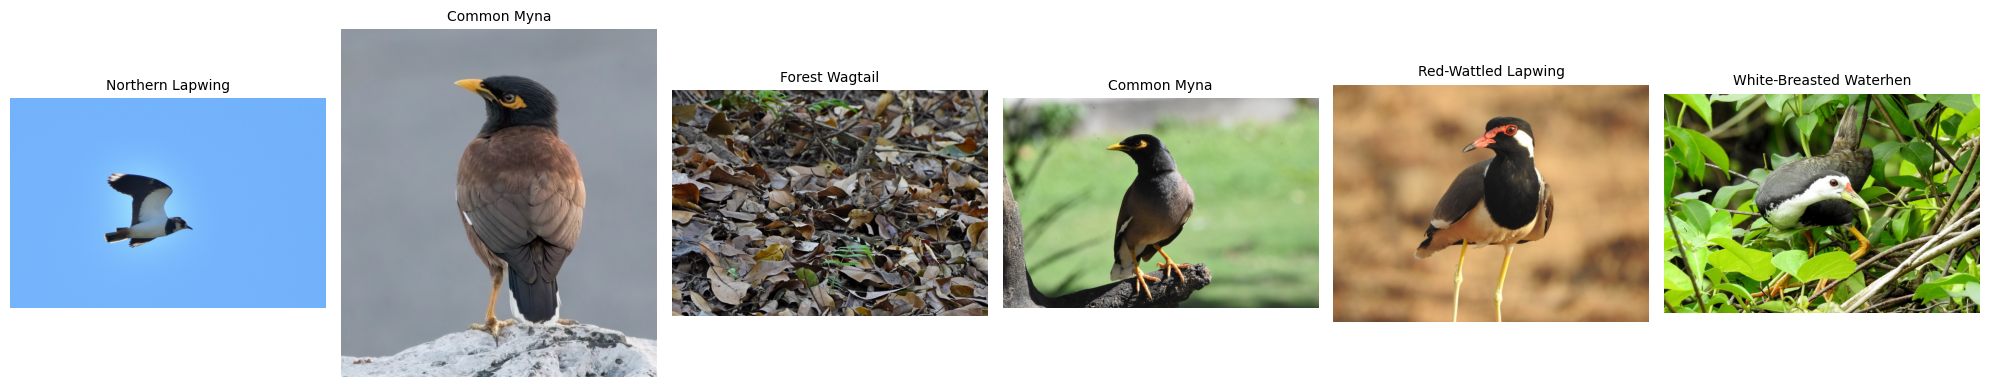


--- Sample Images from training_data (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data) ---
No images found in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Extract species name from the directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to use the actual dataset folders found in cell IXEO7kTkTmB8
training_set_path = os.path.join(path, 'training_set')
print(f"\n--- Sample Images from training_set ({training_set_path}) ---")
display_sample_images(training_set_path)

training_data_path = os.path.join(path, 'training_data')
print(f"\n--- Sample Images from training_data ({training_data_path}) ---")
display_sample_images(training_data_path)


In [ ]:
import os

# Define the actual path containing the bird species folders
# Based on previous results, it is located in training_set/training_set
input_folder = os.path.join(path, 'training_set', 'training_set')
output_folder = '/content/bird_dataset_split'

if not os.path.exists(input_folder):
    # Fallback if the directory structure is not nested
    input_folder = os.path.join(path, 'training_set')

print(f"Preparing to split data from: {input_folder}")

Preparing to split data from: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set/training_set


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Split the dataset: train=0.8, test=0.2
# seed=42 to ensure reproducibility
# We are splitting into train and val (using val as the test set as requested)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Data split successfully into folder: {output_folder}")

Copying files: 22620 files [00:41, 550.80 files/s]

Data split successfully into folder: /content/bird_dataset_split


In [ ]:
# Check the directory structure after splitting
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 2: # Only print up to species level to avoid long output
        print(f"{indent}{os.path.basename(root)}/")

bird_dataset_split/
    train/
        Coppersmith Barbet/
        Rufous Treepie/
        Sarus Crane/
        White-Breasted Waterhen/
        Northern Lapwing/
        Indian Pitta/
        House Crow/
        Forest Wagtail/
        Common Rosefinch/
        Common Tailorbird/
        Red-Wattled Lapwing/
        Ruddy Shelduck/
        Indian Grey Hornbill/
        Asian Green Bee-Eater/
        Brown-Headed Barbet/
        White Wagtail/
        Common Myna/
        Gray Wagtail/
        Jungle Babbler/
        Cattle Egret/
        Indian Peacock/
        White-Breasted Kingfisher/
        Common Kingfisher/
        Hoopoe/
        Indian Roller/
    val/
        Coppersmith Barbet/
        Rufous Treepie/
        Sarus Crane/
        White-Breasted Waterhen/
        Northern Lapwing/
        Indian Pitta/
        House Crow/
        Forest Wagtail/
        Common Rosefinch/
        Common Tailorbird/
        Red-Wattled Lapwing/
        Ruddy Shelduck/
        Indian Grey Hornb

In [ ]:
import os

def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"New dataset statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%)")
print(f"- Total: {total} images")

New dataset statistics:
- Train Set: 18090 images (80.0%)
- Test Set (val): 4530 images (20.0%)
- Total: 22620 images


In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Colab settings (Runtime > Change runtime type).')
else:
    print(f'Found GPU at: {device_name}')

# Display GPU details
!nvidia-smi

Found GPU at: /device:GPU:0
Wed Jul 29 23:29:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P0             27W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers

# Image configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build VGG16 model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Found 18090 images belonging to 25 classes.
Found 4530 images belonging to 25 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,143,897 (80.66 MB)

 Trainable params: 6,429,209 (24.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Training the model
EPOCHS = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

Epoch 1/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 609s 1s/step - accuracy: 0.1716 - loss: 2.8297 - val_accuracy: 0.4371 - val_loss: 2.1747
Epoch 2/10
  1/565 ━━━━━━━━━━━━━━━━━━━━ 1:41 181ms/step - accuracy: 0.1875 - loss: 2.8072

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


565/565 ━━━━━━━━━━━━━━━━━━━━ 74s 131ms/step - accuracy: 0.1875 - loss: 2.8072 - val_accuracy: 0.4371 - val_loss: 2.1770
Epoch 3/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 623s 1s/step - accuracy: 0.3019 - loss: 2.3710 - val_accuracy: 0.5379 - val_loss: 1.7710
Epoch 4/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 73s 129ms/step - accuracy: 0.2812 - loss: 2.4444 - val_accuracy: 0.5390 - val_loss: 1.7745
Epoch 5/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 562s 994ms/step - accuracy: 0.3772 - loss: 2.1325 - val_accuracy: 0.5955 - val_loss: 1.5722
Epoch 6/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 73s 130ms/step - accuracy: 0.4688 - loss: 1.8903 - val_accuracy: 0.5933 - val_loss: 1.5699
Epoch 7/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 562s 994ms/step - accuracy: 0.4180 - loss: 1.9794 - val_accuracy: 0.6148 - val_loss: 1.4543
Epoch 8/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 72s 128ms/step - accuracy: 0.4375 - loss: 1.9021 - val_accuracy: 0.6133 - val_loss: 1.4565
Epoch 9/10
565/565 ━━━━━━━━━━━━━━━━━━━━ 560s 992ms/step - accuracy: 0.4458 - loss: 1.8828 - va

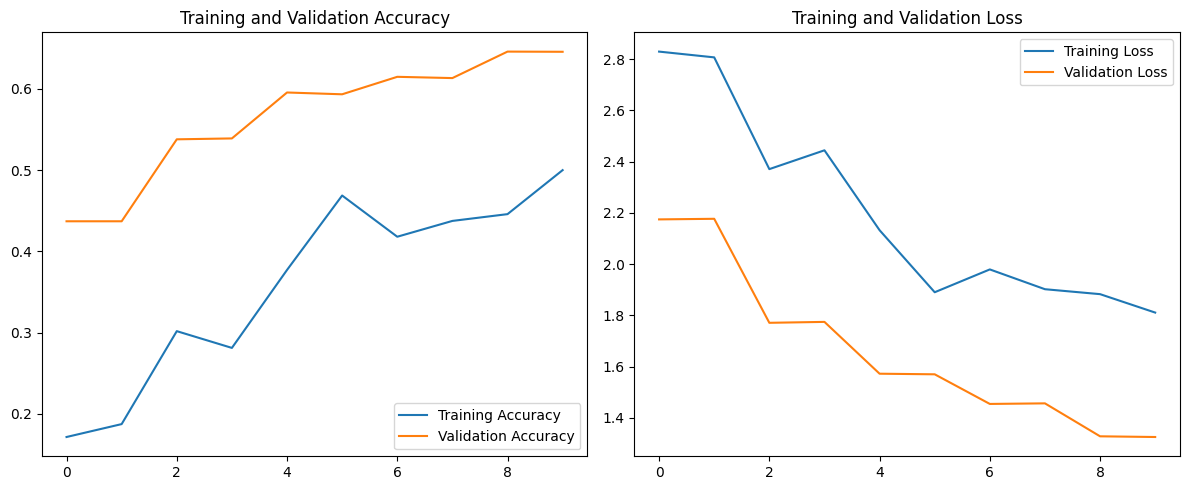

In [ ]:
import matplotlib.pyplot as plt

# Summarize history for accuracy and loss
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_training_history(history)